# Tutorial 4: Data Augmentation

Data augmentation is an integral process in deep learning because these models require large amounts of data. In cases where it is not feasible to collect thousands or millions of images, data augmentation helps increase the size of the dataset and introduces necessary variability.

---

## Step 1: Importing Necessary Libraries

First, we import the libraries required for image processing, augmentation, and file system operations.

In [1]:
import matplotlib.pyplot as plt # For displaying images [cite: 9]
from tensorflow.keras.preprocessing.image import ImageDataGenerator # For image augmentation [cite: 9, 11]
from tensorflow.keras.utils import img_to_array, load_img # For loading and converting images to arrays [cite: 10, 12]
import os # For creating directories and handling file system operations [cite: 13]

---

## Step 2: Define the Folder Where Augmented Images Will Be Saved

We define a directory to store our new images. If the folder does not exist, the script will create it.

In [2]:
# [cite_start]Define the folder where augmented images will be saved [cite: 16]
save_folder = r"augmented_images"

# [cite_start]Create the folder if it doesn't exist [cite: 17]
os.makedirs(save_folder, exist_ok=True)

---

## Step 3: Initialize the ImageDataGenerator with Augmentation Parameters

We configure the `ImageDataGenerator` class with specific transformations to apply to the images.

*
**Rotation**: Rotates the image within a specified range (up to 40 degrees).


*
**Shear**: Introduces geometric transformations by skewing the image.


*
**Zoom**: Randomly zooms in or out by 20%.


*
**Horizontal Flip**: Randomly flips the image horizontally.


*
**Brightness**: Randomly adjusts brightness between 50% and 150%.

In [3]:
# [cite_start]Initialize the ImageDataGenerator class with augmentation parameters [cite: 20]
datagen = ImageDataGenerator(
    rotation_range=40,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.5, 1.5)
)

---

## Step 4: Load the Image and Convert It to a NumPy Array

Keras works with NumPy arrays, so we must convert the loaded JPEG image into this format.

In [4]:
# [cite_start]Load the sample image from the given path [cite: 38]
# Note: Ensure 'Image.jpg' exists in your Colab file sidebar
img = load_img("Image.jpg")

# [cite_start]Convert the loaded image into a Numpy array [cite: 40]
x = img_to_array(img)

---

## Step 5: Reshape the Image for Batch Processing

The `ImageDataGenerator` expects a 4D array with the shape `(batch_size, height, width, channels)`. Since we are using one image, we add an extra dimension.

In [5]:
# [cite_start]Reshape the image to add an extra dimension for batch processing [cite: 44]
x = x.reshape((1,) + x.shape)

---

## Step 6: Generate and Save Augmented Images

We create a loop to generate 40 augmented images, save them to our folder, and display them using Matplotlib.

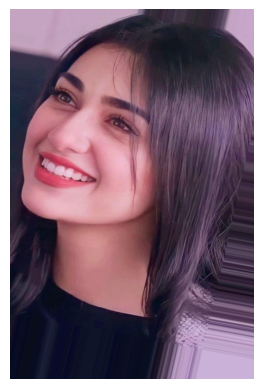

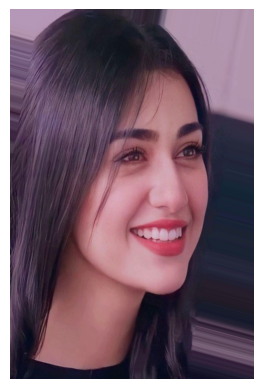

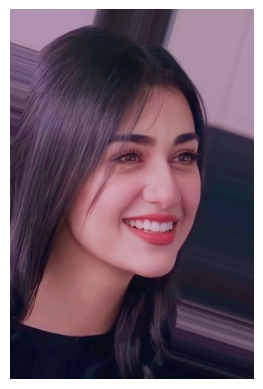

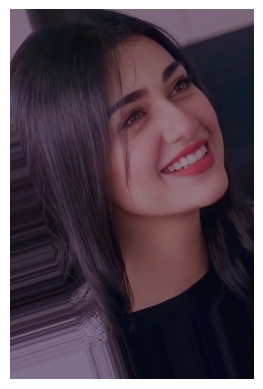

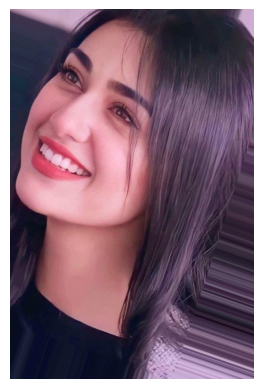

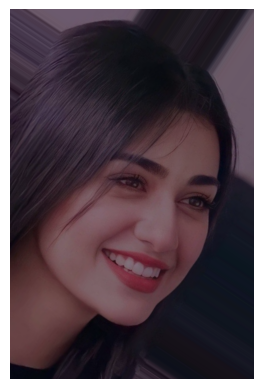

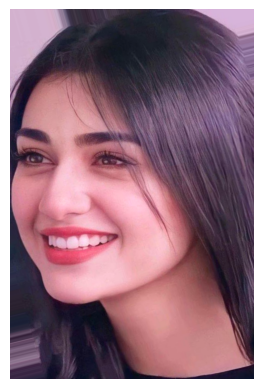

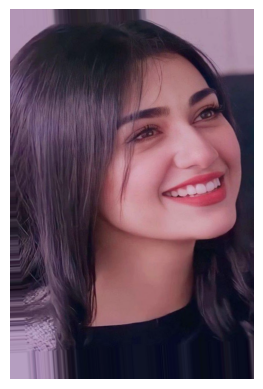

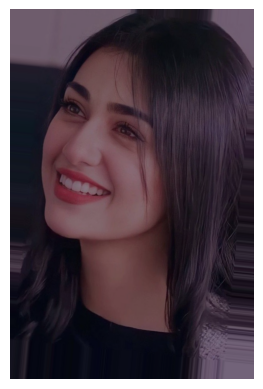

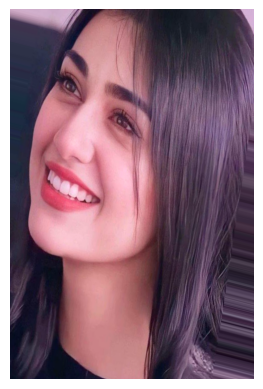

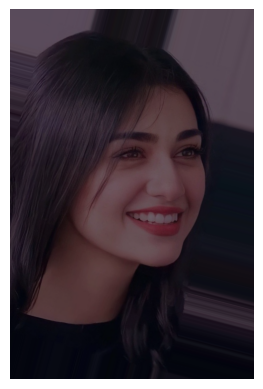

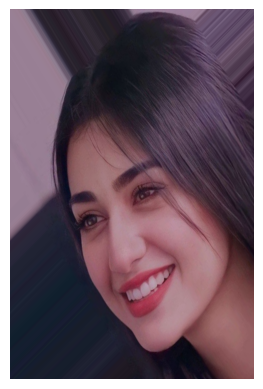

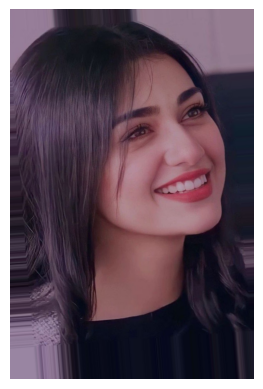

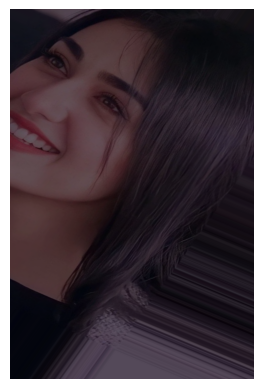

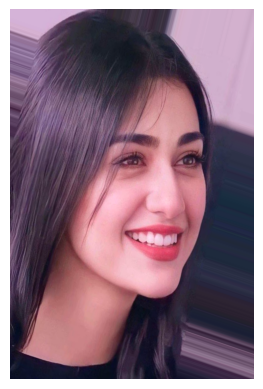

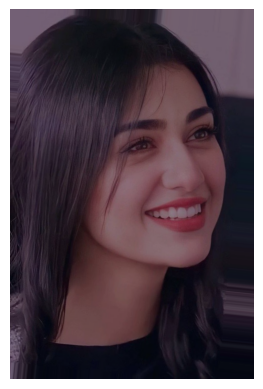

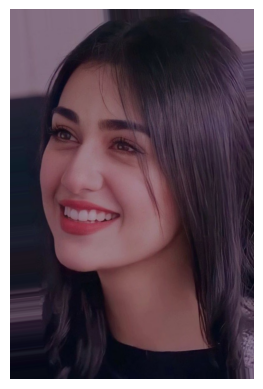

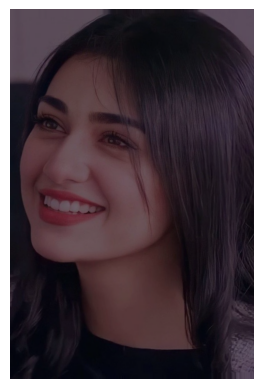

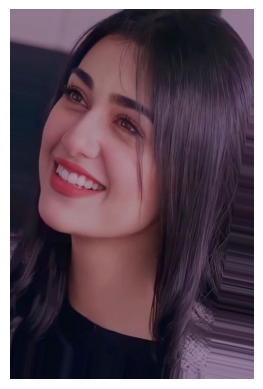

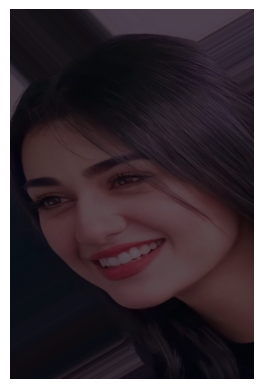

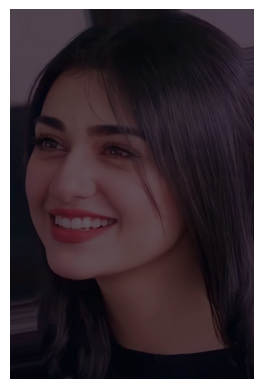

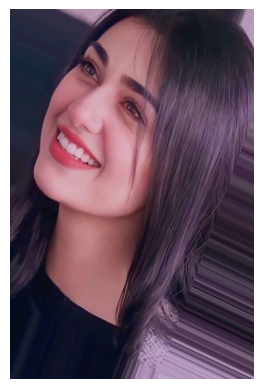

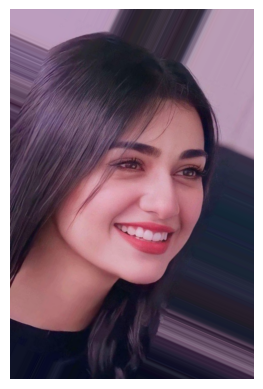

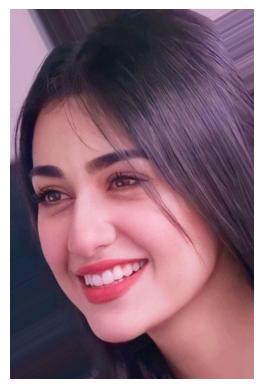

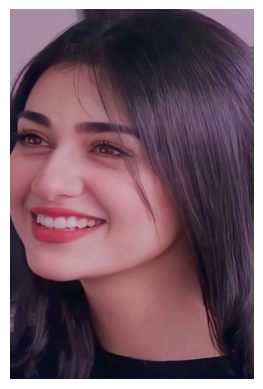

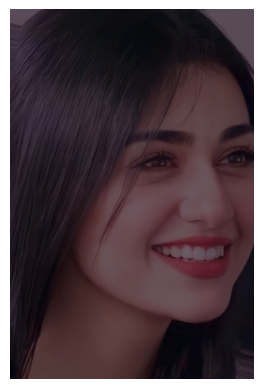

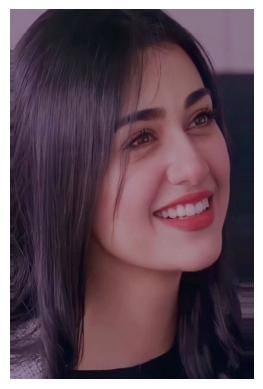

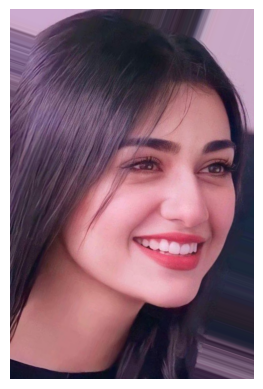

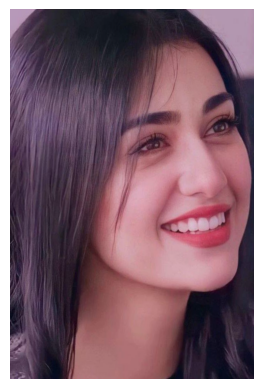

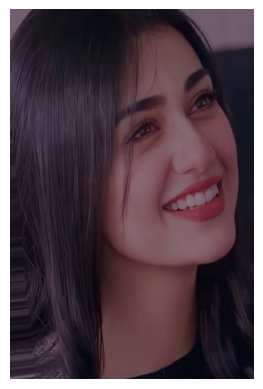

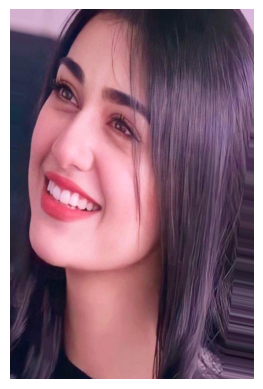

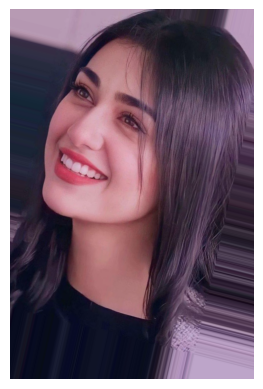

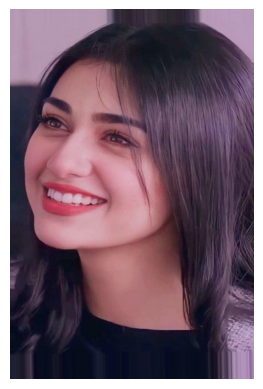

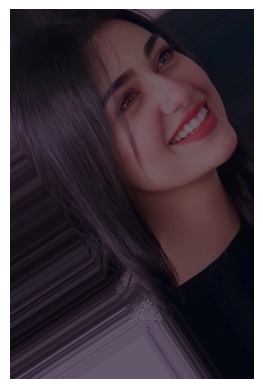

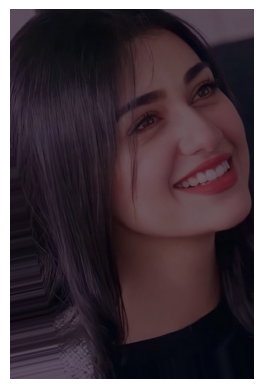

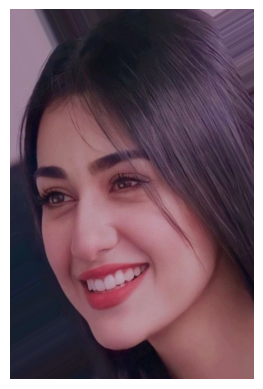

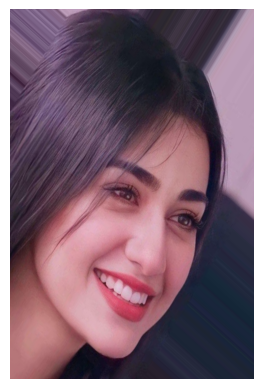

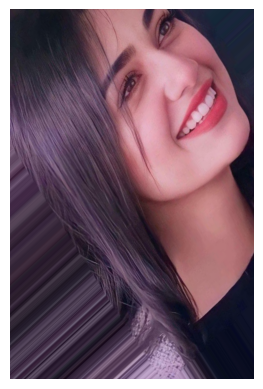

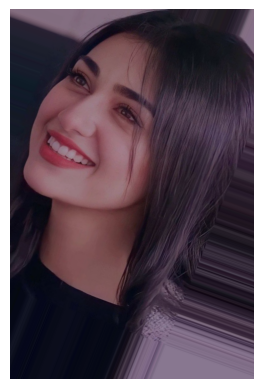

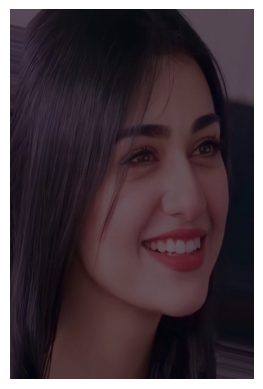

In [6]:
# [cite_start]Initialize a counter to limit the number of augmented images generated [cite: 47]
i = 0

# [cite_start]Loop to generate and save augmented images [cite: 48, 49]
for batch in datagen.flow(x, batch_size=1,
                          save_to_dir=save_folder,
                          save_prefix='aug_image',
                          save_format='jpeg'):
    # [cite_start]Convert the batch back to an image for visualization [cite: 55, 56]
    augmented_image = batch[0].astype('uint8')

    # [cite_start]Display the augmented image using matplotlib [cite: 58]
    plt.figure()
    plt.imshow(augmented_image)
    plt.axis('off')
    plt.show()

    i += 1
    # [cite_start]Stop after generating 40 images as per task requirements [cite: 65, 74]
    if i >= 40:
       break

---

## Step 7: Confirm the Saved Location

Finally, we verify the absolute path where the images were stored.

In [7]:
# [cite_start]Print the location of saved augmented images [cite: 69]
print(f"Augmented images are saved in the folder: {os.path.abspath(save_folder)}")

Augmented images are saved in the folder: /content/augmented_images


## **TASK 1 : DATA AUGMENTATION USING PYTORCH ON PICTURE FROM MY OWN COMPUTER**

Starting augmentation...


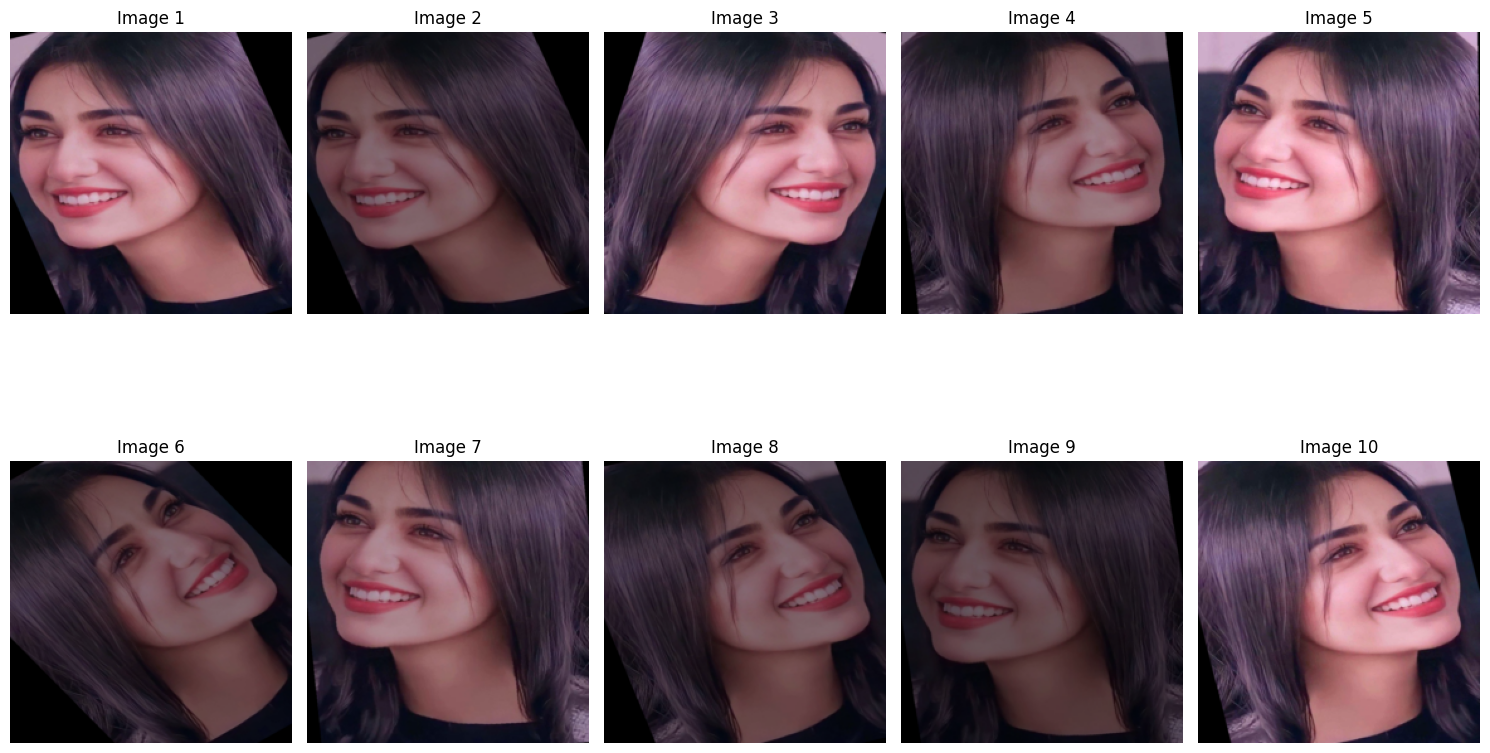


SUCCESS: 40 images generated.
Location: /content/Augmented_Images_PyTorch


In [8]:
# ==========================================
# TUTORIAL 4: DATA AUGMENTATION (PYTORCH)
# ==========================================

import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

# --- STEP 1 & 2: Setup Save Directory ---
save_folder = "Augmented_Images_PyTorch"
os.makedirs(save_folder, exist_ok=True)

# --- STEP 3: Define Augmentation Parameters ---
# This matches the Keras logic: Rotation, Shear, Zoom, Flip, and Brightness
augmentation_pipeline = transforms.Compose([
    transforms.RandomRotation(degrees=40),
    transforms.RandomAffine(degrees=0, shear=0.2), # Shear
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)), # Zoom/Crop
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.5), # Brightness (0.5 to 1.5 range)
    transforms.ToTensor()
])

# --- STEP 4 & 5: Load Image ---
# IMPORTANT: Ensure you have uploaded a file named 'Image.jpg' to the Colab sidebar
image_path = "Image.jpg"

if not os.path.exists(image_path):
    print(f"Error: {image_path} not found. Please upload the image to Colab.")
else:
    img = Image.open(image_path).convert("RGB")

    # --- STEP 6: Generate, Save, and Display 40 Images ---
    print("Starting augmentation...")
    plt.figure(figsize=(15, 10))

    for i in range(40):
        # Apply transformation
        augmented_tensor = augmentation_pipeline(img)

        # Convert back to PIL to save
        augmented_img = transforms.ToPILImage()(augmented_tensor)

        # Save the image
        file_name = f"aug_image_{i+1}.jpeg"
        save_path = os.path.join(save_folder, file_name)
        augmented_img.save(save_path)

        # Display the first 10 images in a grid for preview
        if i < 10:
            plt.subplot(2, 5, i + 1)
            plt.imshow(augmented_img)
            plt.title(f"Image {i+1}")
            plt.axis('off')

    plt.tight_layout()
    plt.show()

    # --- STEP 7: Confirm Location ---
    print(f"\nSUCCESS: 40 images generated.")
    print(f"Location: {os.path.abspath(save_folder)}")